# 🔬 Exploring Unitary Transformations

In the previous notebooks we used the Hadamard gate to create superposition.  But *why* does the Hadamard gate work?  The answer lies in a deep mathematical property: **every quantum gate is a unitary transformation**.

This notebook explores what that means, why it matters, and how to see it in action.

## Setup & imports

We use **Qiskit** with its built‑in `BasicSimulator`.

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import random
from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector

## Unitary Transformations

### What is a unitary matrix?

A square matrix $U$ is **unitary** if its conjugate‑transpose (denoted $U^\dagger$) is also its inverse:

$$U\,U^\dagger = U^\dagger\,U = I$$

where $I$ is the identity matrix.

### Key properties

| Property                                        | What it means                                                        | Why it matters for QC                                                                                                             |
|-------------------------------------------------|----------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------|
| **Norm‑preserving**                             | $\lVert U\lvert\psi\rangle \rVert = \lVert \lvert\psi\rangle \rVert$ | The length of state vector is preserved on the Bloch sphere and is always 1, meaning probabilities always sum to 1 after the gate |
| **Reversible**                                  | $U^\dagger$ undoes $U$                                               | Every quantum gate can be *un‑done*                                                                                               |
| **Some Unitary operators are Hermetian**        | $H = H^\dagger$ | By applying same operation, we undo the transform.                                                                                |
| **Determinant**                                 | $                                                                    | \det(U)                                                                                                                           | = 1$ | Ensures no information is created or lost |
| **Maps orthonormal bases to orthonormal bases** | If $\langle i                                                        | j \rangle = \delta_{ij}$, then $\langle i                                                                                         | U^\dagger U | j \rangle = \delta_{ij}$ | Measurement outcomes remain well‑defined |

**In quantum computing, every gate applied to qubits is a unitary matrix.**  
This is not just a mathematical convenience — it is a fundamental law of quantum mechanics:  
closed‑system evolution is *always* unitary. No information is lost and all processes can be reversed in time!

### Demo — Verifying unitarity

Let's verify $U\,U^\dagger = I$ for the common single‑qubit gates: **I**, **X**, **Z**, **H**, **S**, and **T**.

In [28]:
gate_names = ["I", "X", "Z", "H", "S", "T"]

def build_single_gate_circuit(gate_name: str) -> QuantumCircuit:
    """Return a 1‑qubit circuit that applies the named gate."""
    qc = QuantumCircuit(1)
    if   gate_name == "I": qc.id(0)
    elif gate_name == "X": qc.x(0)
    elif gate_name == "Z": qc.z(0)
    elif gate_name == "H": qc.h(0)
    elif gate_name == "S": qc.s(0)
    elif gate_name == "T": qc.t(0)
    return qc

print("Gate  |  U·U† == I ?  |  Matrix")
print("-" * 60)
for name in gate_names:
    qc = build_single_gate_circuit(name)
    U = Operator(qc)
    product = U.adjoint().compose(U)           # U† · U
    is_identity = np.allclose(product.data, np.eye(2))
    print(f"  {name}   |  {str(is_identity):>5}        |  {np.array2string(U.data, precision=3, suppress_small=True)}")

print()
print("✅  Every standard quantum gate is unitary.")

Gate  |  U·U† == I ?  |  Matrix
------------------------------------------------------------
  I   |   True        |  [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
  X   |   True        |  [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
  Z   |   True        |  [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
  H   |   True        |  [[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
  S   |   True        |  [[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
  T   |   True        |  [[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]

✅  Every standard quantum gate is unitary.


### Demo — Norm preservation

The **Born rule** says the probability of measuring outcome $k$ is $|\alpha_k|^2$.  
Total probability must stay 1 before and after any gate:

$$|\alpha|^2 + |\beta|^2 = 1 \;\;\Longrightarrow\;\; |\alpha'|^2 + |\beta'|^2 = 1$$

Let's check this numerically for several gates applied to an arbitrary state.

In [29]:
# Start with an arbitrary (normalised) state:  0.6|0⟩ + 0.8|1⟩
psi = Statevector([0.6, 0.8])
print(f"Initial state : {psi.data}")
print(f"Initial norm² : {sum(abs(a)**2 for a in psi.data):.6f}")
print()

states = []
for name in gate_names:
    qc = build_single_gate_circuit(name)
    psi_out = psi.evolve(qc)
    states.append(psi_out.copy())
    norm_sq = sum(abs(a)**2 for a in psi_out.data)
    print(f"After {name}: {psi_out.data}  norm² = {norm_sq:.6f}")

print()
print("✅  Norm is preserved — probabilities always sum to 1.")

Initial state : [0.6+0.j 0.8+0.j]
Initial norm² : 1.000000

After I: [0.6+0.j 0.8+0.j]  norm² = 1.000000
After X: [0.8+0.j 0.6+0.j]  norm² = 1.000000
After Z: [ 0.6+0.j -0.8+0.j]  norm² = 1.000000
After H: [ 0.98994949+0.j -0.14142136+0.j]  norm² = 1.000000
After S: [0.6+0.j  0. +0.8j]  norm² = 1.000000
After T: [0.6       +0.j         0.56568542+0.56568542j]  norm² = 1.000000

✅  Norm is preserved — probabilities always sum to 1.


## Bloch Sphere Rotations

On the Bloch sphere, every single‑qubit unitary is a **rotation** (possibly composed with a global phase).  
Different gates rotate the state vector along different axes:

| Gate | Rotation | Bloch‑sphere effect |
|:----:|:--------:|:-------------------:|
| X    | $\pi$ around **x‑axis** | Bit‑flip: $\lvert0\rangle \leftrightarrow \lvert1\rangle$ |
| Z    | $\pi$ around **z‑axis** | Phase‑flip: $\lvert1\rangle \to -\lvert1\rangle$ |
| H    | $\pi$ around **(x+z)/$\sqrt{2}$** axis | Creates / destroys superposition |
| S    | $\pi/2$ around **z‑axis** | Quarter‑turn phase |
| T    | $\pi/4$ around **z‑axis** | Eighth‑turn phase |

Below we visualise the effect of each gate on $\lvert0\rangle$.

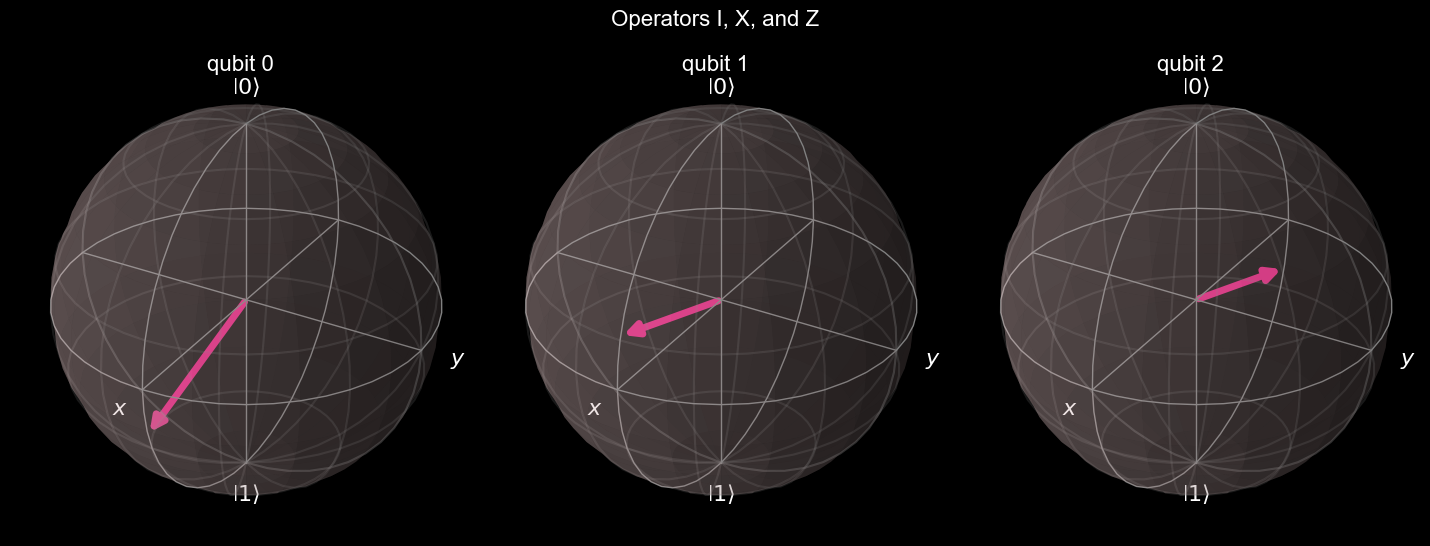

In [30]:
qc_states_p1 = QuantumCircuit(3)
qc_states_p2 = QuantumCircuit(3)
for idx, state in enumerate(states):
    if idx < 3:
        qc_states_p1.initialize(state.data, idx)
    else:
        qc_states_p2.initialize(state.data, idx-3)
multi_qubit_state = Statevector.from_instruction(qc_states_p1)
plot_bloch_multivector(multi_qubit_state,
                       title="Operators I, X, and Z",
                       font_size=16)

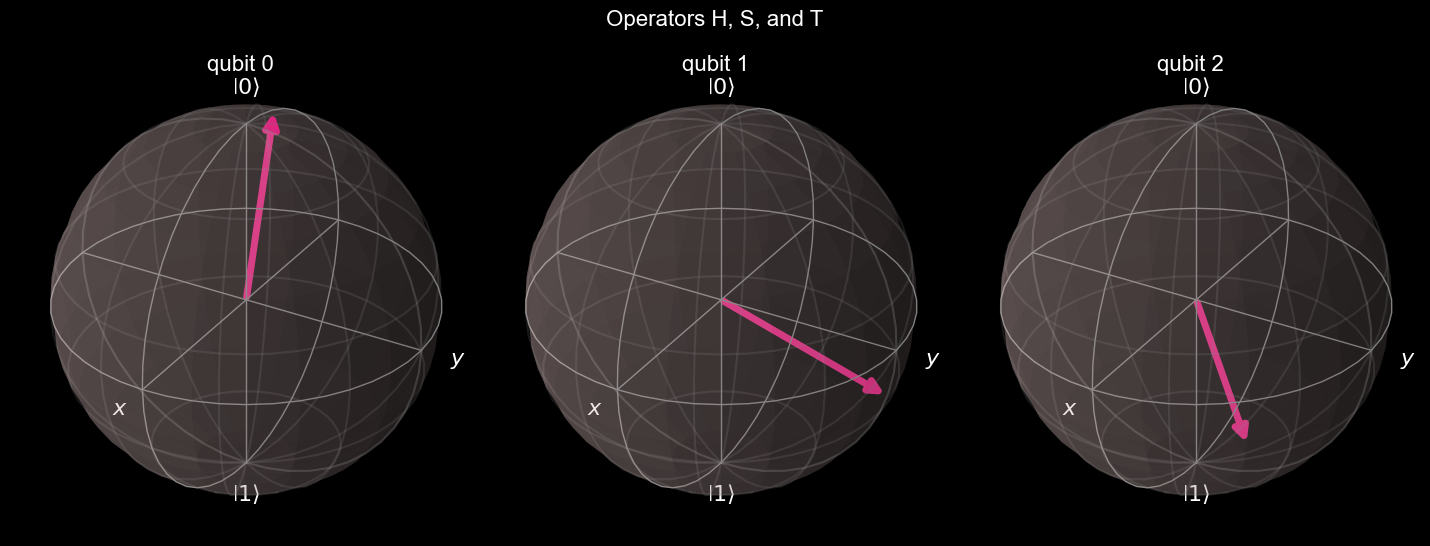

In [31]:
multi_qubit_state = Statevector.from_instruction(qc_states_p2)
plot_bloch_multivector(multi_qubit_state,
                       title="Operators H, S, and T",
                       font_size=16)


## Reversibility: $U^\dagger U = I$

Classical logic gates like **AND** / **OR** are *irreversible* — you cannot recover the inputs from the output.  
Every quantum gate is reversible: applying $U^\dagger$ (the *adjoint*) **exactly** undoes $U$.

We already saw this with the Hadamard: $H^2 = I$ (because $H = H^\dagger$).  
Here we show the same for a sequence of gates.

Round‑trip matrix (should be I):
[[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]
✅  U† · U = I confirmed: perfect reversibility.
Forward circuit:
   ┌───┐┌───┐┌───┐┌───┐
q: ┤ H ├┤ T ├┤ S ├┤ Z ├
   └───┘└───┘└───┘└───┘
Round‑trip circuit (forward + inverse):
   ┌───┐┌───┐┌───┐┌───┐┌───┐┌─────┐┌─────┐┌───┐
q: ┤ H ├┤ T ├┤ S ├┤ Z ├┤ Z ├┤ Sdg ├┤ Tdg ├┤ H ├
   └───┘└───┘└───┘└───┘└───┘└─────┘└─────┘└───┘


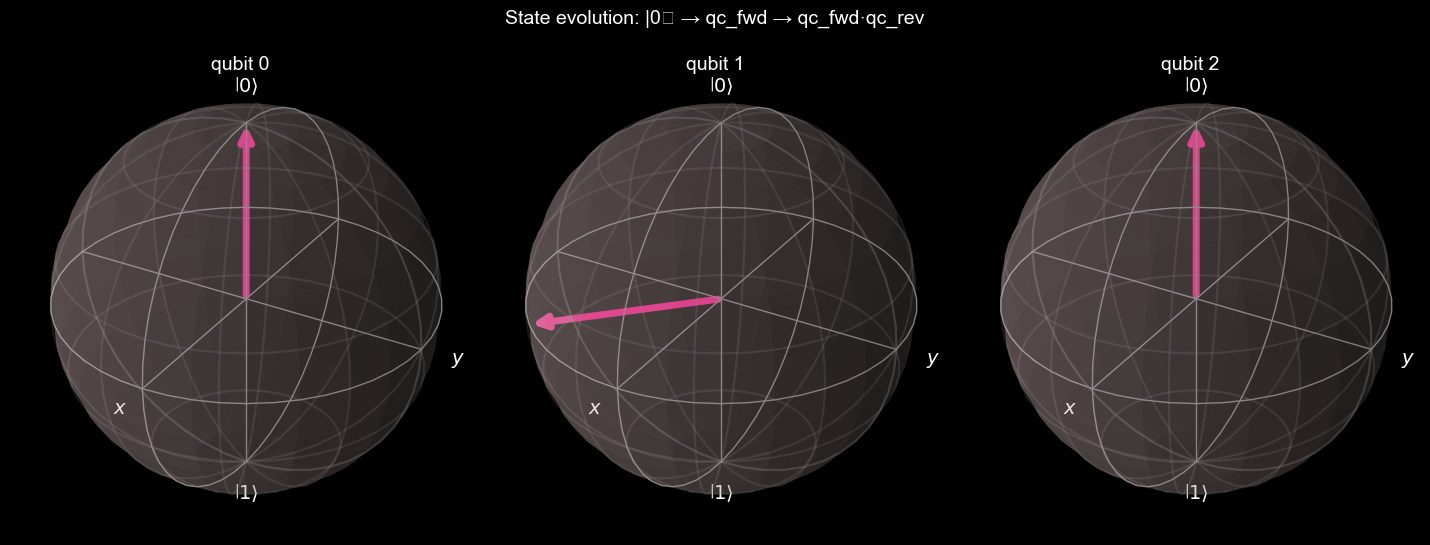

In [32]:
# Apply a sequence of gates, then undo them in reverse order
qc_fwd = QuantumCircuit(1)
qc_fwd.h(0)
qc_fwd.t(0)
qc_fwd.s(0)
qc_fwd.z(0)

# Undo:  Z† · S† · T† · H†  (reverse order, each adjoint)
qc_rev = qc_fwd.inverse()

# Full round‑trip circuit
qc_roundtrip = qc_fwd.compose(qc_rev)

U_roundtrip = Operator(qc_roundtrip)
print("Round‑trip matrix (should be I):")
print(np.array2string(U_roundtrip.data, precision=4, suppress_small=True))
assert np.allclose(U_roundtrip.data, np.eye(2)), "Round‑trip failed!"
print("✅  U† · U = I confirmed: perfect reversibility.")
print("Forward circuit:")
print(qc_fwd.draw(output='text'))
print("Round‑trip circuit (forward + inverse):")
print(qc_roundtrip.draw(output='text'))

# Show state evolution on the Bloch sphere
initial_state = Statevector.from_label('0')
state_after_forward = initial_state.evolve(qc_fwd)
state_after_roundtrip = initial_state.evolve(qc_roundtrip)

state_sequence = [initial_state, state_after_forward, state_after_roundtrip]
qc_bloch = QuantumCircuit(len(state_sequence))
for idx, state in enumerate(state_sequence):
    qc_bloch.initialize(state.data, idx)

evolution_state = Statevector.from_instruction(qc_bloch)
plot_bloch_multivector(
    evolution_state,
    title="State evolution: |0⟩ → qc_fwd → qc_fwd·qc_rev",
    font_size=14
)


## Superposition & Interference via Unitaries

A unitary can **spread** amplitude across basis states (superposition) and later **recombine** amplitudes so they add or cancel (interference).

### Superposition

The Hadamard on $\lvert0\rangle$ spreads amplitude equally:
$$H\lvert0\rangle = \frac{1}{\sqrt2}\lvert0\rangle + \frac{1}{\sqrt2}\lvert1\rangle$$

### Constructive interference

$$H(\alpha\lvert0\rangle+\beta\lvert1\rangle)
= \frac{\alpha+\beta}{\sqrt2}\lvert0\rangle + \frac{\alpha-\beta}{\sqrt2}\lvert1\rangle$$


So for
$$H\lvert0\rangle = \frac{1}{\sqrt2}(\lvert0\rangle+\lvert1\rangle),$$
the output amplitudes become
$$\frac{1+1}{2}\lvert0\rangle + \frac{1-1}{2}\lvert1\rangle = \lvert0\rangle.$$

The $\lvert0\rangle$ contributions add constructively, while the $\lvert1\rangle$ contributions cancel destructively.

Similarly,
$$H\lvert1\rangle = \frac{1}{\sqrt2}(\lvert0\rangle-\lvert1\rangle),$$
so a second Hadamard gives
$$\frac{1-1}{2}\lvert0\rangle + \frac{1+1}{2}\lvert1\rangle = \lvert1\rangle.$$

The relative phase (the minus sign) changes which output amplitudes cancel and which reinforce.

Superposition creates the possibility of interference; phase controls it; later unitaries reveal it.

**Interference is the computational engine of quantum algorithms.** The Deutsch algorithm exploits exactly this pattern.

It is not merely “being in superposition.” It is what happens when a later unitary combines coherent amplitudes for the same possible outcome, causing them to reinforce or cancel depending on relative phase.

## Black‑Box Description and Quantum Gates

### The oracle model

In many quantum algorithms the core problem is:

> *Given an unknown function $f$ encoded as a **unitary** (an "oracle" $U_f$), determine some global property of $f$ using as few queries to $U_f$ as possible.*

Because $U_f$ is unitary, we can:
1. **Prepare** qubits in superposition (spread amplitude over all inputs simultaneously).
2. **Query** $U_f$ once — it acts on the entire superposition at the same time.
3. **Interfere** the resulting amplitudes so that the desired property is readable from measurement.

This is the source of **quantum advantage**: a classical computer must query $f$ one input at a time; a quantum computer queries all inputs in *one* shot via superposition.

### Mathematical notation

A standard way to encode a classical Boolean function $f:\{0,1\}\to\{0,1\}$ into a unitary is the **phase oracle**:

$$U_f \lvert x\rangle = (-1)^{f(x)}\lvert x\rangle$$

Or, equivalently, the **bit‑flip oracle** using an ancilla qubit $\lvert y\rangle$:

$$U_f \lvert x\rangle\lvert y\rangle = \lvert x\rangle\lvert y \oplus f(x)\rangle$$

where $\oplus$ is addition mod 2 (XOR).

Both forms are unitary — they preserve norms and are reversible.  The Deutsch algorithm (next notebook) uses this to distinguish **constant** from **balanced** functions with a single query.

### Demo — Building an oracle as a unitary

Consider the four possible single‑bit Boolean functions $f:\{0,1\}\to\{0,1\}$:

| Oracle | $f(0)$ | $f(1)$ | Type |
|:------:|:------:|:------:|:--------:|
| $f_1$  |   0    |   0    | constant |
| $f_2$  |   1    |   1    | constant |
| $f_3$  |   0    |   1    | balanced |
| $f_4$  |   1    |   0    | balanced |

We implement each as a **2‑qubit bit‑flip oracle** $U_f\lvert x\rangle\lvert y\rangle = \lvert x\rangle\lvert y \oplus f(x)\rangle$ and verify the resulting unitary matrix.

In [35]:
def make_oracle(name: str) -> QuantumCircuit:
    """
    Build U_f for the four 1-bit Boolean functions.
    Qubit 0 = input x, Qubit 1 = target y.
    U_f|x⟩|y⟩ = |x⟩|y ⊕ f(x)⟩
    """
    qc = QuantumCircuit(2, name=name)

    if name == "f1":           # f(0)=0, f(1)=0  → identity (do nothing)
        pass
    elif name == "f2":         # f(0)=1, f(1)=1  → always flip target
        qc.x(1)
    elif name == "f3":         # f(0)=0, f(1)=1  → CNOT (flip target iff x=1)
        qc.cx(0, 1)
    elif name == "f4":         # f(0)=1, f(1)=0  → flip target, then CNOT
        qc.x(1)
        qc.cx(0, 1)

    return qc


for fname in ["f1", "f2", "f3", "f4"]:
    oracle = make_oracle(fname)
    U = Operator(oracle)

    # Verify unitarity
    assert np.allclose(U.adjoint().compose(U).data, np.eye(4)), f"{fname} is not unitary!"

    print(f"Oracle {fname}  (unitary ✅)")
    print(oracle.draw(output='text'))

    # Evaluate f on each input classically via the oracle
    for x_val in [0, 1]:
        # Prepare |x⟩|0⟩ and apply U_f
        qc_test = QuantumCircuit(2)
        if x_val == 1:
            qc_test.x(0)
        qc_test = qc_test.compose(oracle)
        sv = Statevector.from_instruction(qc_test)
        probs = sv.probabilities_dict()
        # The target qubit (qubit 1) tells us f(x)
        # In Qiskit bit ordering, '01' means q0=1, q1=0
        f_val = 0
        for bitstring, p in probs.items():
            if p > 0.5:
                f_val = int(bitstring[0])  # MSB = qubit 1 in Qiskit
        print(f"   f({x_val}) = {f_val}")
    print()

Oracle f1  (unitary ✅)
     
q_0: 
     
q_1: 
     
   f(0) = 0
   f(1) = 0

Oracle f2  (unitary ✅)
          
q_0: ─────
     ┌───┐
q_1: ┤ X ├
     └───┘
   f(0) = 1
   f(1) = 1

Oracle f3  (unitary ✅)
          
q_0: ──■──
     ┌─┴─┐
q_1: ┤ X ├
     └───┘
   f(0) = 0
   f(1) = 1

Oracle f4  (unitary ✅)
               
q_0: ───────■──
     ┌───┐┌─┴─┐
q_1: ┤ X ├┤ X ├
     └───┘└───┘
   f(0) = 1
   f(1) = 0



### Preview — The Deutsch trick

Classically, you need **2 queries** to $f$ to tell constant from balanced ($f(0)$ *and* $f(1)$).  
The Deutsch algorithm uses superposition + interference to do it in **1 query**:

$$\lvert0\rangle \xrightarrow{H} \frac{\lvert0\rangle+\lvert1\rangle}{\sqrt2}
  \xrightarrow{U_f}
  \xrightarrow{H} \begin{cases}
  \lvert0\rangle & \text{if } f \text{ is constant} \\
  \lvert1\rangle & \text{if } f \text{ is balanced}
  \end{cases}$$

This is the quintessential example of **quantum advantage through unitary interference**, and the subject of the next notebook.

In [36]:
# Quick preview: run the Deutsch circuit for each oracle
print("Deutsch algorithm preview (1 query to U_f):")
print("=" * 50)

for fname in ["f1", "f2", "f3", "f4"]:
    oracle = make_oracle(fname)

    # Deutsch circuit
    qc_d = QuantumCircuit(2, 1)
    qc_d.x(1)          # ancilla |1⟩
    qc_d.h(0)          # input in superposition
    qc_d.h(1)          # ancilla in |−⟩
    qc_d = qc_d.compose(oracle)  # single query
    qc_d.h(0)          # interference
    qc_d.measure(0, 0) # measure input qubit

    compiled = transpile(qc_d, backend, seed_transpiler=42)
    result = backend.run(compiled, shots=1000, seed_simulator=42).result()
    counts = result.get_counts()

    measured = max(counts, key=counts.get)
    classification = "constant" if measured == "0" else "balanced"
    print(f"  {fname}: measured |{measured}⟩ → {classification}   (counts: {counts})")

print()
print("✅  All four oracles classified correctly with a single query!")

Deutsch algorithm preview (1 query to U_f):
  f1: measured |0⟩ → constant   (counts: {'0': 1000})
  f2: measured |0⟩ → constant   (counts: {'0': 1000})
  f3: measured |1⟩ → balanced   (counts: {'1': 1000})
  f4: measured |1⟩ → balanced   (counts: {'1': 1000})

✅  All four oracles classified correctly with a single query!


## Composing Unitaries

The product of two unitary matrices is also unitary:

$$(U_2 U_1)(U_2 U_1)^\dagger = U_2 U_1 U_1^\dagger U_2^\dagger = U_2 I U_2^\dagger = I$$

This means **any quantum circuit** (a sequence of gates) is itself a single unitary transformation.  
Qiskit lets us inspect the overall matrix:

In [37]:
qc_composed = QuantumCircuit(1)
qc_composed.h(0)
qc_composed.t(0)
qc_composed.h(0)

U_composed = Operator(qc_composed)
print("Circuit:")
print(qc_composed.draw(output='text'))
print()
print("Overall unitary matrix (H · T · H):")
print(np.array2string(U_composed.data, precision=4, suppress_small=True))
print()

# Verify the product is still unitary
product = U_composed.adjoint().compose(U_composed)
assert np.allclose(product.data, np.eye(2))
print("✅  Composition of unitaries is still unitary.")

Circuit:
   ┌───┐┌───┐┌───┐
q: ┤ H ├┤ T ├┤ H ├
   └───┘└───┘└───┘

Overall unitary matrix (H · T · H):
[[0.8536+0.3536j 0.1464-0.3536j]
 [0.1464-0.3536j 0.8536+0.3536j]]

✅  Composition of unitaries is still unitary.


## Universality: Any unitary from a small gate set

A remarkable theorem in quantum computing:

> **Any** $n$‑qubit unitary can be approximated to arbitrary precision using only **H**, **T**, and **CNOT**.

This is analogous to how **NAND** alone can build any classical circuit.  
The $\{H, T, \text{CNOT}\}$ set is called a **universal gate set**.

Here we show that **H** and **T** alone can produce rotations at many different angles around the Bloch sphere.

Font 'default' does not have a glyph for '\u27e9' [U+27e9], substituting with a dummy symbol.
C:\Users\bmilanovic\AppData\Local\Temp\ipykernel_4176\3335380814.py:41: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
Font 'default' does not have a glyph for '\u27e9' [U+27e9], substituting with a dummy symbol.


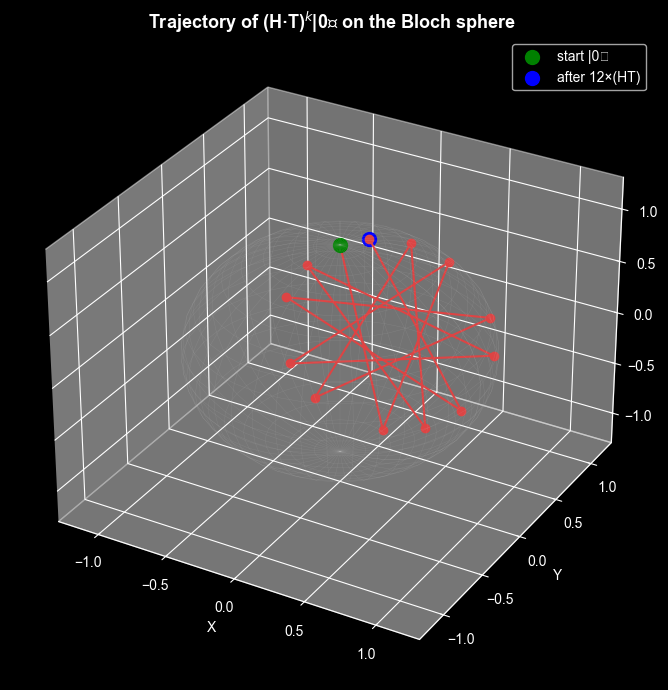

Each (H·T) step rotates the state to a new point on the Bloch sphere.
With enough H and T gates, we can reach any point → universal single-qubit control.


In [38]:
# Apply increasing numbers of (H·T) pairs to see the state walk around the Bloch sphere
n_steps = 12
bloch_vectors = []

for k in range(n_steps + 1):
    qc = QuantumCircuit(1)
    for _ in range(k):
        qc.h(0)
        qc.t(0)
    state = Statevector.from_instruction(qc)
    alpha, beta = state.data
    x = 2 * np.real(alpha * np.conj(beta))
    y = 2 * np.imag(alpha * np.conj(beta))
    z = abs(alpha)**2 - abs(beta)**2
    bloch_vectors.append((x, y, z))

# 3D plot
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Sphere wireframe
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 20)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(xs, ys, zs, color='lightgrey', alpha=0.15, linewidth=0.3)

# Plot trajectory
bx = [bv[0] for bv in bloch_vectors]
by = [bv[1] for bv in bloch_vectors]
bz = [bv[2] for bv in bloch_vectors]
ax.plot(bx, by, bz, 'o-', color='#DD4444', markersize=6, linewidth=1.5)
ax.scatter([bx[0]], [by[0]], [bz[0]], color='green', s=100, zorder=5, label='start |0⟩')
ax.scatter([bx[-1]], [by[-1]], [bz[-1]], color='blue', s=100, zorder=5, label=f'after {n_steps}×(HT)')

ax.set_title("Trajectory of (H·T)$^k$|0⟩ on the Bloch sphere", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim([-1.3, 1.3]); ax.set_ylim([-1.3, 1.3]); ax.set_zlim([-1.3, 1.3])
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
plt.tight_layout()
plt.show()

print("Each (H·T) step rotates the state to a new point on the Bloch sphere.")
print("With enough H and T gates, we can reach any point → universal single-qubit control.")

## Takeaways

| Concept | Key point |
|:--------|:----------|
| **Unitary** | $U U^\dagger = I$ — every quantum gate satisfies this |
| **Norm‑preserving** | Probabilities always sum to 1 after any gate |
| **Reversible** | $U^\dagger$ exactly undoes $U$ — no information is lost |
| **Bloch rotation** | Every 1‑qubit unitary is a rotation on the Bloch sphere |
| **Superposition** | Unitaries spread amplitude across basis states |
| **Interference** | Unitaries recombine amplitudes; phase determines constructive vs destructive |
| **Oracle model** | Classical functions encoded as unitaries can be queried in superposition |
| **Universality** | {H, T, CNOT} can approximate *any* unitary to arbitrary precision |

**Next notebook:** We use these ideas in the **Deutsch Algorithm** — the simplest example of quantum advantage through unitary interference.